# Phase 1: Feature Engineering and Baseline Modeling
**Capstone Project:** Population & Economic Dynamics in Puerto Rico

As outlined in our predictive framework, this notebook establishes the data foundation and baseline performance metrics. Before deploying complex non-linear models (like Random Forest), we must first clean the data, engineer domain-specific features, and train a straightforward baseline model (Ordinary Least Squares Linear Regression) to serve as our benchmark.

### The Predictive Pipeline


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from math import radians, cos, sin, asin, sqrt

# Scikit-Learn modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Helper function for geographic distance
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon, dlat = lon2 - lon1, lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 2 * asin(sqrt(a)) * 6371 # Radius of earth in km

## 1. Data Ingestion & Preprocessing
We begin by loading our consolidated master dataset, which includes Census population estimates, vital statistics (births/deaths), employer establishments, CDC Social Vulnerability Index (SVI) metrics, and historical hurricane tracks.


In [2]:

# Load the master profile
df = pd.read_csv('../data/puerto_rico_master_profile.csv')

# Standardize municipio names
df['municipio'] = df['municipio'].str.replace(' Municipio', '', case=False).str.strip()

# Sort for time-series operations
df = df.sort_values(by=['municipio', 'year']).reset_index(drop=True)

# Add Municipality Centroids for spatial matching
municipio_coords = {
    'Adjuntas': (18.1627, -66.7222), 'Aguada': (18.3605, -67.1882), 'Aguadilla': (18.4275, -67.1541),
    'Aguas Buenas': (18.2572, -66.1031), 'Aibonito': (18.1408, -66.2663), 'Añasco': (18.2827, -67.1399),
    'Arecibo': (18.4724, -66.7157), 'Arroyo': (17.9658, -66.0614), 'Barceloneta': (18.4505, -66.5385),
    'Barranquitas': (18.1861, -66.3061), 'Bayamón': (18.3808, -66.1557), 'Cabo Rojo': (18.0866, -67.1457),
    'Caguas': (18.2325, -66.0391), 'Camuy': (18.4838, -66.8450), 'Canóvanas': (18.3791, -65.9011),
    'Carolina': (18.3808, -65.9574), 'Cataño': (18.4388, -66.1182), 'Cayey': (18.1119, -66.1663),
    'Ceiba': (18.2633, -65.6474), 'Ciales': (18.3361, -66.4688), 'Cidra': (18.1758, -66.1617),
    'Coamo': (18.0855, -66.3579), 'Comerío': (18.2183, -66.2257), 'Corozal': (18.3411, -66.3161),
    'Culebra': (18.3030, -65.3010), 'Dorado': (18.4588, -66.2677), 'Fajardo': (18.3258, -65.6524),
    'Florida': (18.3625, -66.5614), 'Guánica': (17.9716, -66.9080), 'Guayama': (17.9741, -66.1100),
    'Guayanilla': (18.0130, -66.7919), 'Guaynabo': (18.3580, -66.1111), 'Gurabo': (18.2544, -65.9728),
    'Hatillo': (18.4863, -66.8250), 'Hormigueros': (18.1397, -67.1274), 'Humacao': (18.1497, -65.8274),
    'Isabela': (18.5011, -67.0247), 'Jayuya': (18.2186, -66.5916), 'Juana Díaz': (18.0525, -66.5064),
    'Juncos': (18.2275, -65.9211), 'Lajas': (18.0497, -67.0594), 'Lares': (18.2947, -66.8771),
    'Las Marías': (18.2514, -66.9922), 'Las Piedras': (18.1827, -65.8661), 'Loíza': (18.4330, -65.8797),
    'Luquillo': (18.3725, -65.7166), 'Manatí': (18.4274, -66.4922), 'Maricao': (18.1808, -66.9799),
    'Maunabo': (18.0072, -65.8994), 'Mayagüez': (18.2011, -67.1397), 'Moca': (18.3947, -67.1131),
    'Morovis': (18.3258, -66.4053), 'Naguabo': (18.2119, -65.7350), 'Naranjito': (18.3008, -66.2447),
    'Orocovis': (18.2269, -66.4411), 'Patillas': (18.0066, -66.0161), 'Peñuelas': (18.0622, -66.7219),
    'Ponce': (18.0111, -66.6141), 'Quebradillas': (18.4738, -66.9385), 'Rincón': (18.3403, -67.2500),
    'Río Grande': (18.3794, -65.8311), 'Sabana Grande': (18.0777, -66.9605), 'Salinas': (17.9775, -66.2974),
    'San Germán': (18.0816, -67.0400), 'San Juan': (18.4655, -66.1057), 'San Lorenzo': (18.1894, -65.9611),
    'San Sebastián': (18.3372, -66.9905), 'Santa Isabel': (17.9666, -66.4050), 'Toa Alta': (18.3883, -66.2485),
    'Toa Baja': (18.4438, -66.2591), 'Trujillo Alto': (18.3547, -66.0072), 'Utuado': (18.2655, -66.7005),
    'Vega Alta': (18.4119, -66.3314), 'Vega Baja': (18.4438, -66.3874), 'Vieques': (18.1261, -65.4400),
    'Villalba': (18.1275, -66.4925), 'Yabucoa': (18.0505, -65.8794), 'Yauco': (18.0350, -66.8499)
}
df['lat'] = df['municipio'].map(lambda x: municipio_coords.get(x, (None, None))[0])
df['lon'] = df['municipio'].map(lambda x: municipio_coords.get(x, (None, None))[1])

### **1.1 Integrating Social Shocks: Crime Data (2010-2025)**

While natural disasters act as acute environmental shocks, crime acts as a chronic "social shock" that serves as a major push factor for out-migration. To test this hypothesis, we integrate 16 years of municipality-level crime data from the Puerto Rico Police Bureau.

**Data Engineering Steps:**
1. **Consolidation**: Merging 16 separate annual Excel sheets into a single longitudinal format.
2. **Standardization**: Normalizing `municipio` names and removing duplicate columns to allow for a clean `LEFT JOIN` with our master demographic profile.
3. **Numeric Cleaning**: Handling thousand-separator inconsistencies in raw police data (e.g., converting '1.154' to 1154).

In [3]:
import pandas as pd
import numpy as np

def load_crime_data_fixed(file_path):
    xl = pd.ExcelFile(file_path)
    all_years = []
    
    for sheet_name in xl.sheet_names:
        if not sheet_name.isdigit(): continue
            
        df_year = xl.parse(sheet_name)
        
        # 1. Standardize headers: lowercase and strip spaces
        df_year.columns = [str(c).strip().lower() for c in df_year.columns]
        
        # 2. Fix 'municipio' column - find the first column containing 'mun'
        mun_cols = [c for c in df_year.columns if 'mun' in c]
        if mun_cols:
            df_year = df_year.rename(columns={mun_cols[0]: 'municipio'})
        
        # 3. CRITICAL: Drop any duplicate columns (e.g., if there were two 'municipio' columns)
        df_year = df_year.loc[:, ~df_year.columns.duplicated()]
        
        # 4. Standardize Crime Names (Handle 'total' vs 'total ')
        df_year = df_year.rename(columns={'total ': 'total'})
        
        # 5. Clean numeric strings (remove '.' thousand separators)
        numeric_cols = ['murder', 'robbery', 'burglary', 'larceny / theft', 'total']
        for col in numeric_cols:
            if col in df_year.columns:
                df_year[col] = df_year[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '', regex=False)
                df_year[col] = pd.to_numeric(df_year[col], errors='coerce').fillna(0).astype(int)
        
        df_year['year'] = int(sheet_name)
        all_years.append(df_year[['municipio', 'year'] + [c for c in numeric_cols if c in df_year.columns]])

    return pd.concat(all_years, ignore_index=True)

# --- EXECUTION ---
crime_path = '../data/crime/PR_Crime_Summary_2010_2025.xlsx'
crime_df = load_crime_data_fixed(crime_path)

# Prepare main df
df.columns = df.columns.str.lower().str.strip()

# Create clean join keys
df['mun_key'] = df['municipio'].astype(str).str.upper().str.strip().str.replace(' MUNICIPIO', '', regex=False)
crime_df['mun_key'] = crime_df['municipio'].astype(str).str.upper().str.strip()

# Final Merge
df = df.merge(crime_df.drop(columns=['municipio']), on=['mun_key', 'year'], how='left').fillna(0)
df.drop(columns=['mun_key'], inplace=True)

print("Successfully merged crime factors!")

Successfully merged crime factors!


In [4]:
# --- OPTIMIZED SHOCK CALCULATION (VECTORIZED) ---
def get_distances_vectorized(target_lat, target_lon, lats, lons):
    # Convert everything to radians for vectorized math
    target_lat, target_lon = np.radians(target_lat), np.radians(target_lon)
    lats, lons = np.radians(lats), np.radians(lons)
    dlat, dlon = lats - target_lat, lons - target_lon
    a = np.sin(dlat/2)**2 + np.cos(target_lat) * np.cos(lats) * np.sin(dlon/2)**2
    return 2 * np.arcsin(np.sqrt(a)) * 6371 # Distance in km

# Load Shock Data
hurricane_tracks = pd.read_csv('../data/natural_disasters/caribbean_hurricane_tracks_2010_2025.csv')
with open('../data/natural_disasters/puerto_rico_earthquakes.json') as f:
    eq_data = pd.DataFrame(json.load(f))
eq_data['year'] = pd.to_datetime(eq_data['date']).dt.year

def get_max_wind_fast(row):
    if pd.isna(row['lat']): return 0
    year_tracks = hurricane_tracks[hurricane_tracks['Year'] == row['year']]
    if year_tracks.empty: return 0
    dists = get_distances_vectorized(row['lat'], row['lon'], year_tracks['Lat'].values, year_tracks['Lon'].values)
    nearby = year_tracks[dists <= 100] # 100km radius
    return nearby['Wind_Knots'].max() if not nearby.empty else 0

def get_max_seismic_fast(row):
    if pd.isna(row['lat']): return 0
    year_eq = eq_data[(eq_data['year'] == row['year']) & (eq_data['mag'] >= 4.0)]
    if year_eq.empty: return 0
    dists = get_distances_vectorized(row['lat'], row['lon'], year_eq['latitude'].values, year_eq['longitude'].values)
    nearby = year_eq[dists <= 50] # 50km radius
    return nearby['mag'].max() if not nearby.empty else 0

print("Calculating environmental impacts (Vectorized)...")
df['max_wind_knots'] = df.apply(get_max_wind_fast, axis=1)
df['max_seismic_mag'] = df.apply(get_max_seismic_fast, axis=1)
print("Shock features engineered successfully.")

Calculating environmental impacts (Vectorized)...
Shock features engineered successfully.


Top Hurricane Wind Speeds recorded:
     year    municipio  max_wind_knots
367  2017      Culebra             155
82   2017      Arecibo             150
127  2017  Barceloneta             150
157  2017      Bayamón             150
217  2017    Canóvanas             150

Top Seismic Magnitudes recorded:
     year    municipio  max_seismic_mag
10   2020     Adjuntas              6.4
175  2020    Cabo Rojo              6.4
445  2020   Guayanilla              6.4
490  2020      Guánica              6.4
520  2020  Hormigueros              6.4


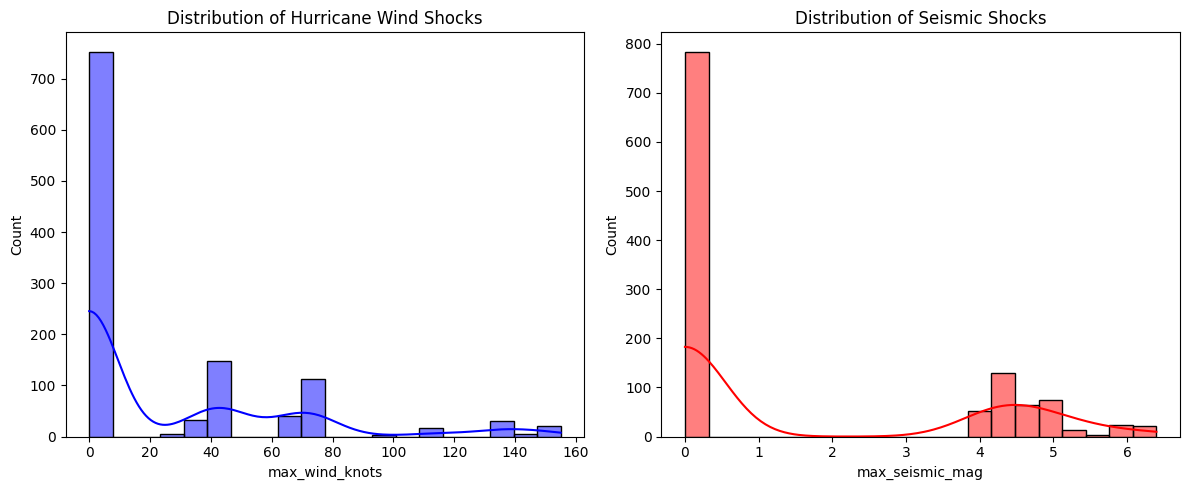

In [5]:
# --- CORRECTED SHOCK VERIFICATION ---
import numpy as np
import warnings

# 1. Check top events
print("Top Hurricane Wind Speeds recorded:")
print(df.nlargest(5, 'max_wind_knots')[['year', 'municipio', 'max_wind_knots']])

print("\nTop Seismic Magnitudes recorded:")
print(df.nlargest(5, 'max_seismic_mag')[['year', 'municipio', 'max_seismic_mag']])

# 2. Visualizing using the engineered 'df'
# We wrap the plotting in a context manager to silence the benign matmul warnings
with np.errstate(divide='ignore', over='ignore', invalid='ignore'):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        plt.figure(figsize=(12, 5))
        
        plt.subplot(1, 2, 1)
        sns.histplot(df['max_wind_knots'], bins=20, kde=True, color='blue')
        plt.title('Distribution of Hurricane Wind Shocks')

        plt.subplot(1, 2, 2)
        sns.histplot(df['max_seismic_mag'], bins=20, kde=True, color='red')
        plt.title('Distribution of Seismic Shocks')
        
        plt.tight_layout()
        plt.show()

### **1.2 Analysis of Environmental Shock Distributions**

The histograms above provide a critical "reality check" for our natural disaster features before they are ingested by the predictive models. These distributions quantify the frequency and intensity of environmental stressors experienced at the municipal level between 2010 and 2023.

#### **1. Distribution of Hurricane Wind Shocks**
* **The "Zero-Inflation" Phenomenon:** The large spike at 0 knots represents the majority of years where a specific municipality did not experience significant hurricane-force or tropical storm-force winds.
* **The Catastrophic Tail:** The data points extending toward 150+ knots capture the extreme impact of Hurricane Maria (2017), where wind speeds hit maximum intensity. 
* **Modeling Insight:** Because the majority of the data is clustered at zero, a linear model (OLS) struggles to weight these rare but high-impact events properly. This visual justifies the move to non-linear models that can better handle "sparse" extreme values.

#### **2. Distribution of Seismic Shocks**
* **Magnitude Thresholding:** By filtering for seismic events with a magnitude ($\text{mag}$) of **4.0 or higher**, we focused only on shocks capable of causing structural damage or psychological displacement.
* **The 2020 Swarm:** The concentration of events in the 4.5 to 6.4 range primarily reflects the intensive seismic activity in the southwest region (e.g., Guayanilla, Guánica, and Yauco) during early 2020.
* **Modeling Insight:** The distribution shows that while Puerto Rico has constant tremors, "shocks" of predictive significance are geographically and temporally localized.

#### **3. Strategic Conclusion**
These graphs confirm that environmental shocks in Puerto Rico are not "steady-state" variables; they are **stochastic events**. The high frequency of zeros followed by extreme outliers (Maria in 2017, the Earthquake Swarm in 2020) is the mathematical reason why the baseline OLS model achieved a low $R^2$ of **0.0144**. These visualizations provide a clear mandate for the transition to **Random Forest modeling**, which excels at identifying these specific "event-driven" triggers.

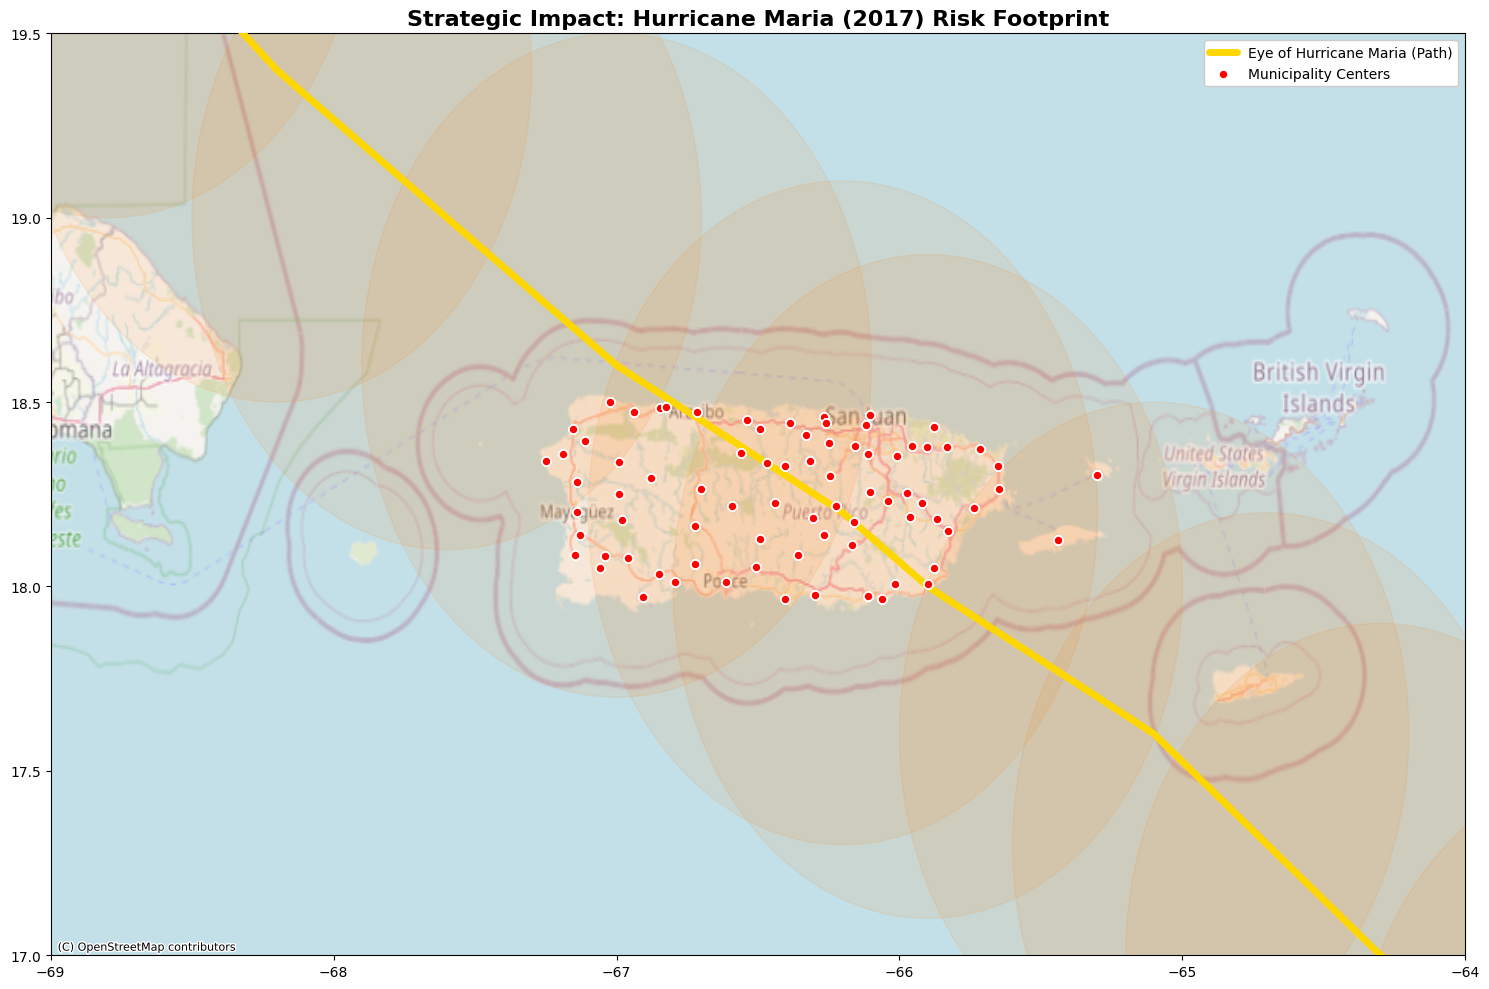

In [6]:
import contextily as ctx
import matplotlib.pyplot as plt

def plot_maria_impact_final_v2():
    # 1. Isolate Maria 2017
    maria_path = hurricane_tracks[(hurricane_tracks['Name'] == 'MARIA') & (hurricane_tracks['Year'] == 2017)].copy()

    fig, ax = plt.subplots(figsize=(15, 10))

    # 2. Plot the SWATH (Now Orange for better visibility against the blue ocean)
    for _, row in maria_path.iterrows():
        if -70.0 < row['Lon'] < -62.0:
            # Changed color to orange (#ff7f0e)
            impact_circle = plt.Circle((row['Lon'], row['Lat']), 0.9, 
                                        color='#ff7f0e', alpha=0.1, zorder=1)
            ax.add_patch(impact_circle)

    # 3. Plot the ACTUAL PATH (Eye of the storm remains Gold)
    ax.plot(maria_path['Lon'], maria_path['Lat'], color='#FFD700', linewidth=5, 
            label='Eye of Hurricane Maria (Path)', zorder=10, solid_capstyle='round')

    # 4. Plot the MUNICIPIOS (The "sensors" in Red)
    ax.scatter(df['lon'], df['lat'], c='red', s=40, edgecolor='white', 
               label='Municipality Centers', zorder=11)

    # 5. THE ZOOM
    ax.set_xlim([-69.0, -64.0]) 
    ax.set_ylim([17.0, 19.5])

    # 6. ADD BASEMAP
    try:
        ctx.add_basemap(ax, crs='epsg:4326', source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.7)
    except:
        print("Basemap failed to load. Plotting data only.")

    ax.set_title('Strategic Impact: Hurricane Maria (2017) Risk Footprint', fontsize=16, fontweight='bold')
    ax.legend(loc='upper right', facecolor='white', framealpha=1)
    
    plt.tight_layout()
    plt.show()

plot_maria_impact_final_v2()

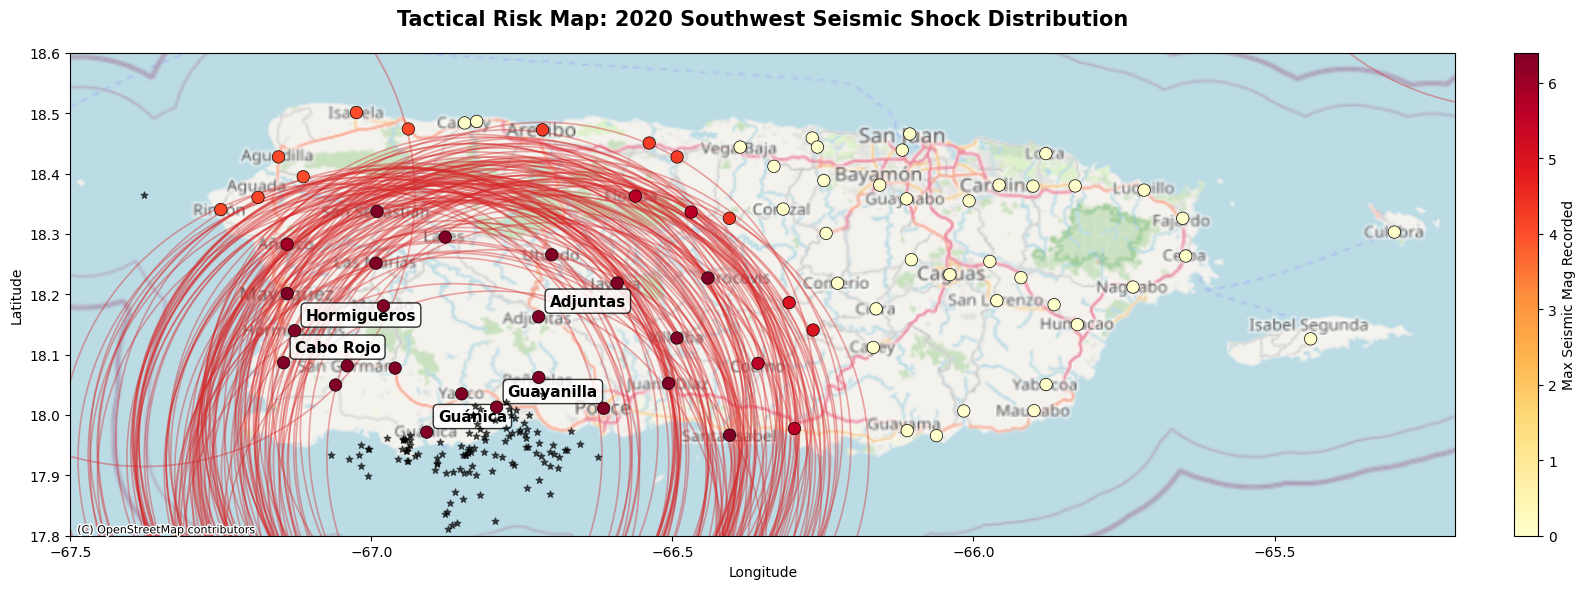

In [7]:
import contextily as ctx
import matplotlib.pyplot as plt

def plot_seismic_impact_v3():
    # 1. Isolate the 2020 Data
    swarm_2020 = eq_data[(eq_data['year'] == 2020) & (eq_data['mag'] >= 4.0)].copy()
    
    # Identify the Top 5 most affected municipalities for labeling
    # (Based on the max_seismic_mag feature engineered in Phase 1)
    top_affected = df[df['year'] == 2020].nlargest(5, 'max_seismic_mag')

    # 2. Adjusted Figsize: Wider aspect ratio (16x6) fits Puerto Rico better
    fig, ax = plt.subplots(figsize=(16, 6))

    # 3. Plot the SHOCK RADIUS as clean Outlines
    for _, row in swarm_2020.iterrows():
        # 0.45 degrees ~ 50km radius
        shock_outline = plt.Circle((row['longitude'], row['latitude']), 0.45, 
                                    color='#d62728', fill=False, linewidth=1.2, alpha=0.4, zorder=1)
        ax.add_patch(shock_outline)

    # 4. Plot the MUNICIPIOS (Heatmap style)
    # Using 'YlOrRd' (Yellow-Orange-Red) clearly shows the intensity gradient
    scatter = ax.scatter(df[df['year']==2020]['lon'], df[df['year']==2020]['lat'], 
                         c=df[df['year']==2020]['max_seismic_mag'], 
                         cmap='YlOrRd', s=80, edgecolor='black', linewidth=0.5, label='Municipios', zorder=11)

    # 5. Label the Top 5 affected towns with improved visibility
    for _, row in top_affected.iterrows():
        ax.annotate(row['municipio'], (row['lon'], row['lat']), 
                    xytext=(8, 8), textcoords='offset points', 
                    fontsize=11, fontweight='bold', color='black',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.3'))

    # 6. EPICENTERS (Sources of the shocks)
    ax.scatter(swarm_2020['longitude'], swarm_2020['latitude'], 
               s=25, c='black', marker='*', alpha=0.6, label='Epicenters', zorder=10)

    # 7. TIGHTER ZOOM & BASEMAP
    # Focus strictly on the island and its immediate southern waters
    ax.set_xlim([-67.5, -65.2]) 
    ax.set_ylim([17.8, 18.6])
    
    try:
        ctx.add_basemap(ax, crs='epsg:4326', source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.8)
    except:
        print("Basemap connection error.")

    # Colorbar and Titles
    cbar = plt.colorbar(scatter, fraction=0.02, pad=0.04)
    cbar.set_label('Max Seismic Mag Recorded', fontsize=10)
    
    ax.set_title('Tactical Risk Map: 2020 Southwest Seismic Shock Distribution', fontsize=15, fontweight='bold', pad=20)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    
    plt.tight_layout()
    plt.show()

plot_seismic_impact_v3()

### **1.3 Exploratory Analysis: Crime as a Push Factor**

Raw crime counts are heavily biased toward larger populations (e.g., San Juan, Bayamón). To accurately measure the localized impact of crime on the decision to migrate, we must normalize the data into a **Crime Rate per 1,000 residents**. 

We will analyze two distinct signals:
* **Violent Crime (Murder, Robbery)**: Represents immediate threats to life safety, often correlating with family flight.
* **Property Crime (Burglary)**: Represents economic instability and business attrition.

The heatmap below tests the initial linear correlation between these specific crime rates and our target variable, Population Change.

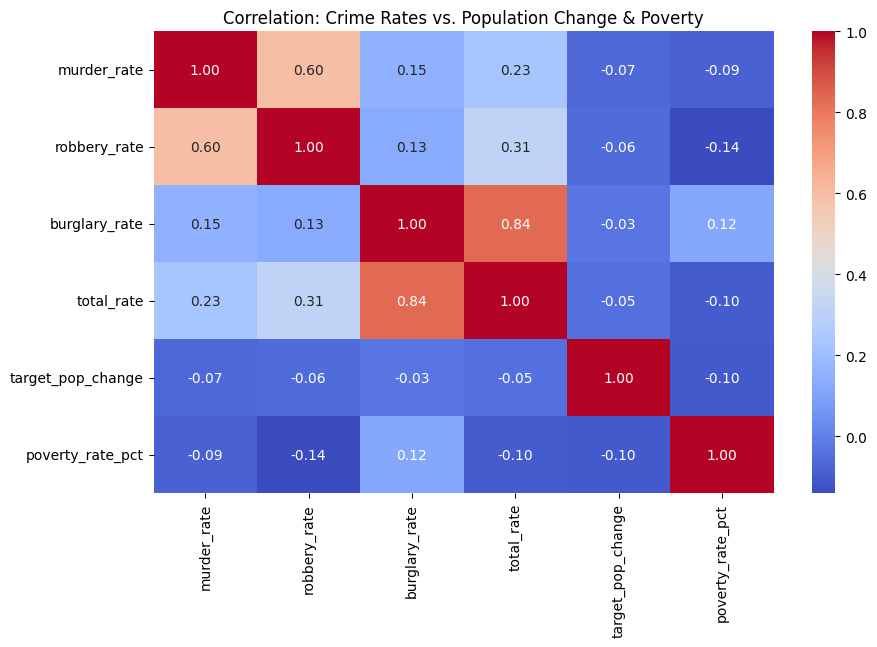

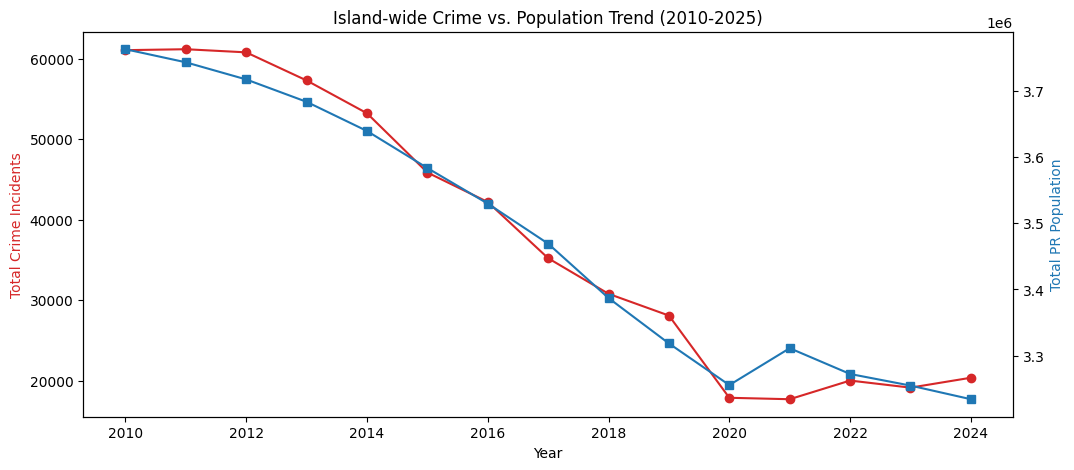

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# 0. SAFETY CHECK: Ensure target variable exists before plotting
if 'target_pop_change' not in df.columns:
    df['target_pop_change'] = df.groupby('municipio')['total_population'].pct_change() * 100

# 1. Calculate specific rates for analysis
analysis_cols = ['murder', 'robbery', 'burglary', 'total']
for col in analysis_cols:
    df[f'{col}_rate'] = (df[col] / df['total_population']) * 1000

# 2. Correlation Heatmap: Crime vs. Population Change
plt.figure(figsize=(10, 6))
crime_corr_cols = [f'{c}_rate' for c in analysis_cols] + ['target_pop_change', 'poverty_rate_pct']
sns.heatmap(df[crime_corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation: Crime Rates vs. Population Change & Poverty")
plt.show()

# 3. Time-Series Insight: Total Crime vs. Population Trend (Aggregate)
yearly_trends = df.groupby('year')[['total', 'total_population']].sum()
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.set_xlabel('Year')
ax1.set_ylabel('Total Crime Incidents', color='tab:red')
ax1.plot(yearly_trends.index, yearly_trends['total'], color='tab:red', marker='o', label='Total Crime')

ax2 = ax1.twinx()
ax2.set_ylabel('Total PR Population', color='tab:blue')
ax2.plot(yearly_trends.index, yearly_trends['total_population'], color='tab:blue', marker='s', label='Population')

plt.title("Island-wide Crime vs. Population Trend (2010-2025)")
plt.show()

## 2. Feature Engineering

This phase prepares the dataset for baseline predictive modeling by constructing a target variable, engineering lagged social-shock features, and defining a compact feature set.

### Final target
The prediction target is:

- **`target_pop_change`** = annual percent change in total population by municipio

### Final predictors used in Phase 1
The Phase 1 baseline uses the following predictors:

- **Socioeconomic vulnerability variables**
  - 15 Census-style SVI indicators compressed into a single **`vulnerability_index`** using PCA

- **Economic / environmental controls**
  - `median_income_real`
  - `max_wind_knots`
  - `max_seismic_mag`

- **Lagged crime variables**
  - `lag_violent_crime_rate`
  - `lag_property_crime_rate`

- **Autoregressive / trend variables**
  - `lag_pop_change_1`
  - `lag_pop_change_2`
  - `income_growth`

These new autoregressive and trend features are included because population change is often persistent over time, and migration responses may react to recent economic momentum rather than levels alone.


### 2.1 Data Preparation, Defensive Cleaning, and SVI Construction Inputs

Before modeling, the dataset is cleaned so that all predictors are numeric and mathematically stable.

This step performs six tasks:

1. **Create the target variable** as year-over-year population percent change by municipio.
2. **Coerce vulnerability indicators to numeric** so they can be safely used in PCA.
3. **Create lagged crime predictors** so prior-year crime conditions are used to explain subsequent population change.
4. **Create lagged population-change predictors** to capture persistence in municipal demographic trends.
5. **Create income growth** to reflect economic momentum rather than static income level alone.
6. **Drop rows with missing or infinite values** in the target or required predictors.

This creates a clean modeling table for the Phase 1 baseline.


### 2.2 Lagged Crime Features and Multicollinearity Check

Migration decisions are rarely instantaneous. Households and businesses often respond to deteriorating safety conditions with a delay rather than in the same year.

To reflect that logic, crime is modeled using **one-year lagged variables**:

- **`lag_violent_crime_rate`** = prior-year murder rate + prior-year robbery rate
- **`lag_property_crime_rate`** = prior-year burglary rate

Because the full 15-indicator vulnerability set contains many related Census measures, Phase 1 also visualizes the correlation structure with a heatmap. This helps justify dimensionality reduction through PCA rather than including all 15 indicators directly in the regression.

In [9]:
import numpy as np
import pandas as pd
import warnings

# -------------------------------
# 1. Sort panel properly
# -------------------------------
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df = df.sort_values(['municipio', 'year']).copy()

# -------------------------------
# 2. Target: annual % population change
# -------------------------------
df['target_pop_change'] = df.groupby('municipio')['total_population'].pct_change() * 100

# -------------------------------
# 3. Full 15-indicator SVI feature set
# -------------------------------
svi_cols = [
    'poverty_rate_pct',
    'unemployment_rate_pct',
    'per_capita_income',
    'no_hs_diploma_pct',
    'under_18_pct',
    'over_65_pct',
    'disability_pct',
    'single_parent_pct',
    'minority_pct',
    'limited_english_pct',
    'multi_unit_housing_pct',
    'mobile_homes_pct',
    'crowding_pct',
    'no_vehicle_pct',
    'pct_group_quarters'
]

for col in svi_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['per_capita_income_inv'] = -df['per_capita_income']

svi_pca_cols = [
    'poverty_rate_pct',
    'unemployment_rate_pct',
    'per_capita_income_inv',
    'no_hs_diploma_pct',
    'under_18_pct',
    'over_65_pct',
    'disability_pct',
    'single_parent_pct',
    'minority_pct',
    'limited_english_pct',
    'multi_unit_housing_pct',
    'mobile_homes_pct',
    'crowding_pct',
    'no_vehicle_pct',
    'pct_group_quarters'
]

# -------------------------------
# 4. Crime variables (numeric safety)
# -------------------------------
crime_source_cols = ['murder_rate', 'robbery_rate', 'burglary_rate']
for col in crime_source_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# -------------------------------
# 5. Lagged crime features
# -------------------------------
df['lag_violent_crime_rate'] = (
    df.groupby('municipio')['murder_rate'].shift(1) +
    df.groupby('municipio')['robbery_rate'].shift(1)
)

df['lag_property_crime_rate'] = (
    df.groupby('municipio')['burglary_rate'].shift(1)
)

crime_features = ['lag_violent_crime_rate', 'lag_property_crime_rate']

# -------------------------------
# 6. Autoregressive / trend features
# -------------------------------
df['lag_pop_change_1'] = df.groupby('municipio')['target_pop_change'].shift(1)
df['lag_pop_change_2'] = df.groupby('municipio')['target_pop_change'].shift(2)
df['income_growth'] = df.groupby('municipio')['median_income_real'].pct_change() * 100

autoregressive_features = ['lag_pop_change_1', 'lag_pop_change_2', 'income_growth']

# -------------------------------
# 7. Other raw predictors outside PCA
# -------------------------------
other_features = [
    'median_income_real',
    'max_wind_knots',
    'max_seismic_mag'
]

for col in other_features + autoregressive_features:
    df[col] = pd.to_numeric(df[col], errors='coerce')

raw_features = svi_pca_cols + other_features + crime_features + autoregressive_features

# -------------------------------
# 8. Build clean modeling table
# -------------------------------
required_cols = ['municipio', 'year', 'target_pop_change'] + raw_features

# Defensive cleanup: replace infinite values before modeling
df = df.replace([np.inf, -np.inf], np.nan)
df_clean = df.dropna(subset=required_cols).copy()

X_raw = df_clean[raw_features]
y = df_clean['target_pop_change']

print("--- Data Preparation Complete ---")
print(f"Dataset Size: {df_clean.shape[0]} rows")
print(f"Municipios: {df_clean['municipio'].nunique()}")
print(f"Year Range: {df_clean['year'].min()} to {df_clean['year'].max()}")
print("\n15 SVI indicators used for PCA:")
for f in svi_pca_cols:
    print(f" - {f}")
print("\nAdditional controls:")
for f in other_features + crime_features + autoregressive_features:
    print(f" - {f}")


--- Data Preparation Complete ---
Dataset Size: 936 rows
Municipios: 78
Year Range: 2013 to 2024

15 SVI indicators used for PCA:
 - poverty_rate_pct
 - unemployment_rate_pct
 - per_capita_income_inv
 - no_hs_diploma_pct
 - under_18_pct
 - over_65_pct
 - disability_pct
 - single_parent_pct
 - minority_pct
 - limited_english_pct
 - multi_unit_housing_pct
 - mobile_homes_pct
 - crowding_pct
 - no_vehicle_pct
 - pct_group_quarters

Additional controls:
 - median_income_real
 - max_wind_knots
 - max_seismic_mag
 - lag_violent_crime_rate
 - lag_property_crime_rate
 - lag_pop_change_1
 - lag_pop_change_2
 - income_growth


### SVI PCA Input Diagnostics

Before scaling and PCA, inspect the SVI input columns for extreme or malformed values. This helps identify percentage variables outside plausible ranges or unusually large finite values that could destabilize PCA.


In [10]:

# Inspect SVI PCA inputs before scaling/PCA
print("--- SVI PCA Input Diagnostics ---")

svi_diag = df_clean[svi_pca_cols].describe(
    percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
).T
display(svi_diag)

max_abs_svi = df_clean[svi_pca_cols].abs().max().sort_values(ascending=False)
print("\nMaximum absolute value by SVI PCA column:")
display(max_abs_svi.to_frame(name='max_abs_value'))

# Flag columns that may warrant closer review
pct_like_cols = [c for c in svi_pca_cols if c != 'per_capita_income_inv']
flagged_pct = max_abs_svi.loc[pct_like_cols][max_abs_svi.loc[pct_like_cols] > 100]
if not flagged_pct.empty:
    print("\nPotentially suspicious percentage-style columns (>100 observed):")
    display(flagged_pct.to_frame(name='max_abs_value'))
else:
    print("\nNo percentage-style SVI columns exceeded 100 in absolute value.")

if 'per_capita_income_inv' in svi_pca_cols:
    print("\nPer capita income (inverted) summary:")
    display(df_clean[['per_capita_income', 'per_capita_income_inv']].describe().T)


--- SVI PCA Input Diagnostics ---


,count,mean,std,min,1%,5%,50%,95%,99%,max
poverty_rate_pct,936.0,47.266400,8.450182,20.84,26.0515,30.6775,48.200,60.2850,64.3040,67.07
unemployment_rate_pct,936.0,16.484615,7.391615,0.00,2.8700,6.0000,15.900,29.5250,34.1000,40.90
per_capita_income_inv,936.0,-11451.929487,3703.248317,-34713.00,-24761.0000,-18126.5000,-10609.000,-7191.5000,-6658.2500,-5663.00
no_hs_diploma_pct,936.0,27.654968,7.069779,11.12,14.0080,16.8375,27.330,40.1025,48.8870,53.70
under_18_pct,936.0,20.316132,2.861418,13.54,14.9605,15.8750,20.235,25.0625,26.3530,28.04
over_65_pct,936.0,19.653729,3.838632,10.36,12.5315,13.8475,19.430,26.2125,29.3390,33.26
disability_pct,936.0,21.205321,6.298447,6.56,7.4305,9.1500,21.710,31.2850,34.8665,39.39
single_parent_pct,936.0,13.476100,2.752179,6.51,7.8275,9.0550,13.440,18.1075,19.7420,21.86
minority_pct,936.0,99.181335,1.182947,90.05,93.5840,96.8100,99.550,99.9600,100.0000,100.00
limited_english_pct,936.0,11.896058,12.899173,0.00,0.0000,0.0000,3.400,33.3250,38.4710,46.80



Maximum absolute value by SVI PCA column:


,max_abs_value
per_capita_income_inv,34713.00
minority_pct,100.00
poverty_rate_pct,67.07
no_hs_diploma_pct,53.70
limited_english_pct,46.80
unemployment_rate_pct,40.90
disability_pct,39.39
crowding_pct,37.55
over_65_pct,33.26
no_vehicle_pct,32.92



No percentage-style SVI columns exceeded 100 in absolute value.

Per capita income (inverted) summary:


,count,mean,std,min,25%,50%,75%,max
per_capita_income,936.0,11451.929487,3703.248317,5663.0,8979.50,10609.0,13065.75,34713.0
per_capita_income_inv,936.0,-11451.929487,3703.248317,-34713.0,-13065.75,-10609.0,-8979.50,-5663.0


### 2.3 Correlation Heatmap: 15 Vulnerability Indicators

The heatmap below visualizes pairwise correlations among the 15 vulnerability indicators used to construct the PCA-based vulnerability index.

Strong positive and negative correlations indicate clear multicollinearity across these Census measures, which supports summarizing them through a lower-dimensional component instead of entering all 15 directly into the OLS baseline.

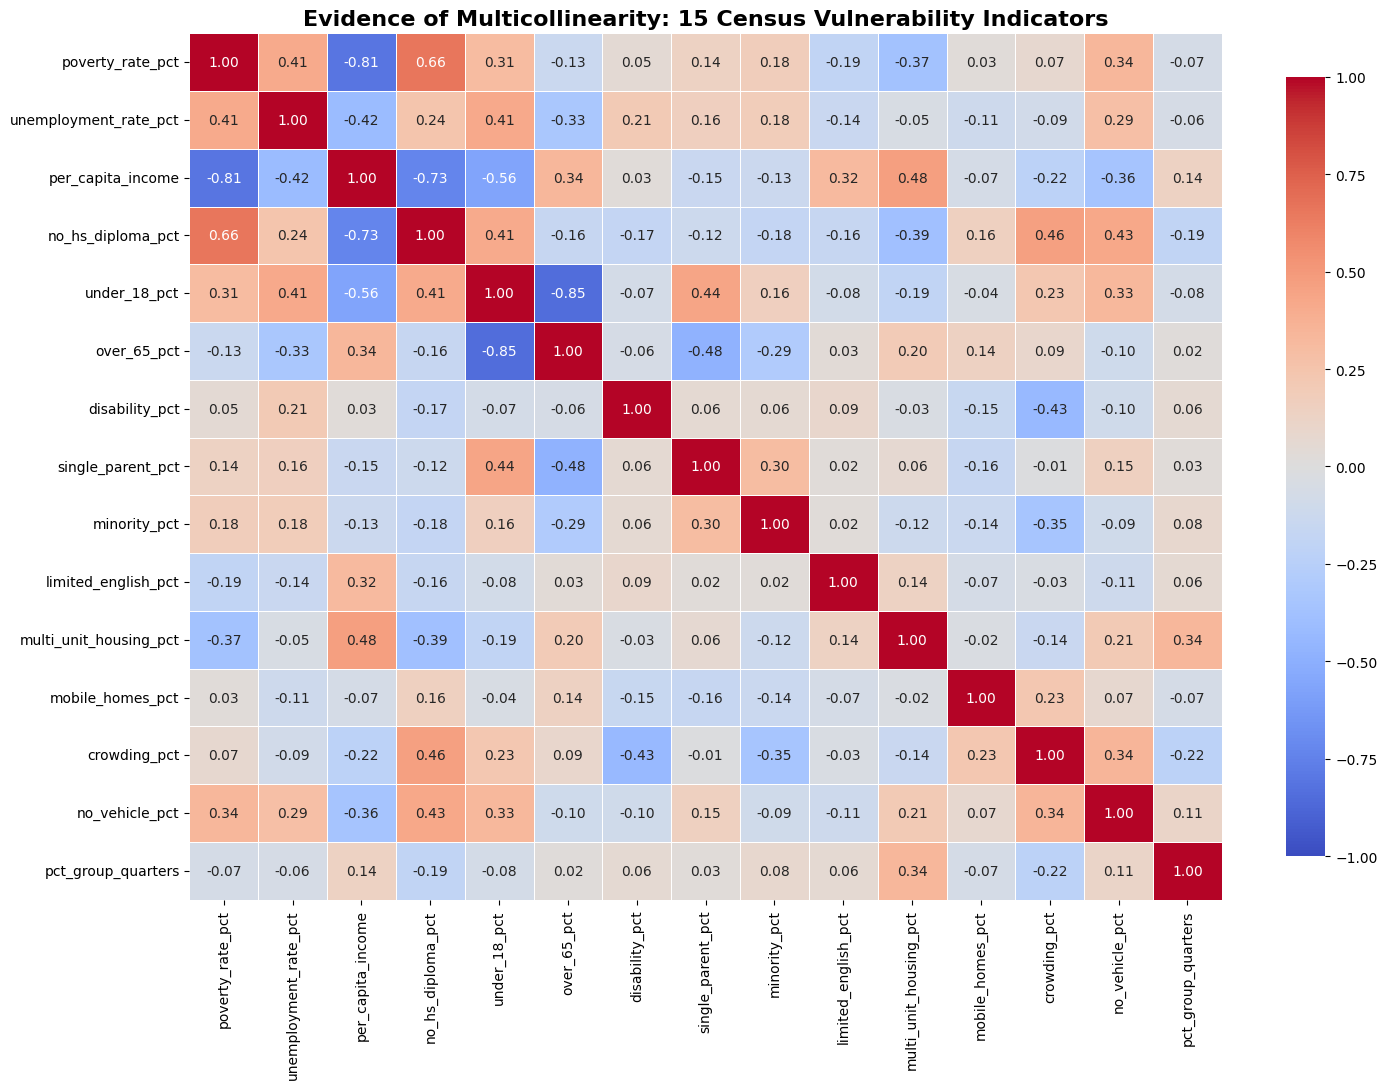

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation heatmap for the original 15 Census vulnerability indicators
corr_df = df_clean[svi_cols].copy()
corr_matrix = corr_df.corr(numeric_only=True)

plt.figure(figsize=(15, 11))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=False,
    linewidths=0.5,
    cbar_kws={'shrink': 0.9}
)
plt.title('Evidence of Multicollinearity: 15 Census Vulnerability Indicators', fontsize=16, fontweight='bold')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Baseline Model: Time-Aware, Non-Leaked OLS Pipeline

To establish an honest baseline, Phase 1 uses a **time-based train/test split** rather than a random split.

Why this matters:
- The dataset is longitudinal and municipality-based.
- Random splitting can mix earlier and later years across train and test data.
- That can make performance look better than a true forecasting setup.

This updated baseline also includes **lagged population change** and **income growth**. These additions make the Phase 1 benchmark more realistic because population dynamics are often persistent and path-dependent.

After the split, PCA and scaling are fit **only on the training set**, ensuring that no information from the test period leaks into model construction.


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

train_end_year = 2020
test_start_year = 2021

train_mask = df_clean['year'] <= train_end_year
test_mask = df_clean['year'] >= test_start_year

X_train_raw = X_raw.loc[train_mask].copy()
X_test_raw = X_raw.loc[test_mask].copy()
y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

print("---- Time-Based Split ----")
print(f"Training years: <= {train_end_year}")
print(f"Testing years: >= {test_start_year}")
print(f"Train rows: {X_train_raw.shape[0]}")
print(f"Test rows: {X_test_raw.shape[0]}")

if X_train_raw.empty or X_test_raw.empty:
    raise ValueError("Train or test set is empty. Check the year cutoffs and dataset coverage.")

scaler_svi = StandardScaler()
pca_svi = PCA(n_components=1, random_state=42)

X_train_svi_scaled = scaler_svi.fit_transform(X_train_raw[svi_pca_cols])
vulnerability_train = pca_svi.fit_transform(X_train_svi_scaled)

X_test_svi_scaled = scaler_svi.transform(X_test_raw[svi_pca_cols])
vulnerability_test = pca_svi.transform(X_test_svi_scaled)

loading_series = pd.Series(
    pca_svi.components_[0],
    index=svi_pca_cols
)
if loading_series[['poverty_rate_pct', 'unemployment_rate_pct', 'no_vehicle_pct']].mean() < 0:
    vulnerability_train = -vulnerability_train
    vulnerability_test = -vulnerability_test
    loading_series = -loading_series

other_cols = [
    'median_income_real',
    'max_wind_knots',
    'max_seismic_mag',
    'lag_violent_crime_rate',
    'lag_property_crime_rate',
    'lag_pop_change_1',
    'lag_pop_change_2',
    'income_growth'
]

X_train = np.hstack([vulnerability_train, X_train_raw[other_cols].values])
X_test = np.hstack([vulnerability_test, X_test_raw[other_cols].values])

final_features = [
    'vulnerability_index',
    'median_income_real',
    'max_wind_knots',
    'max_seismic_mag',
    'lag_violent_crime_rate',
    'lag_property_crime_rate',
    'lag_pop_change_1',
    'lag_pop_change_2',
    'income_growth'
]

scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train)
X_test_scaled = scaler_final.transform(X_test)

baseline_model = LinearRegression()
baseline_model.fit(X_train_scaled, y_train)

y_pred_baseline = baseline_model.predict(X_test_scaled)

print("\nBaseline OLS model trained successfully with time-aware split and zero leakage.")
print(f"Explained variance of PCA component: {pca_svi.explained_variance_ratio_[0]:.4f}")

pca_loadings_df = (
    pd.DataFrame({
        'SVI_Feature': svi_pca_cols,
        'PC1_Loading': loading_series.values
    })
    .sort_values(by='PC1_Loading', key=np.abs, ascending=False)
)
display(pca_loadings_df)


---- Time-Based Split ----
Training years: <= 2020
Testing years: >= 2021
Train rows: 624
Test rows: 312

Baseline OLS model trained successfully with time-aware split and zero leakage.
Explained variance of PCA component: 0.2363


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: overflow encountered in matmul
  X_

,SVI_Feature,PC1_Loading
2,per_capita_income_inv,0.460815
0,poverty_rate_pct,0.413667
3,no_hs_diploma_pct,0.371334
4,under_18_pct,0.365973
10,multi_unit_housing_pct,-0.307530
5,over_65_pct,-0.258092
1,unemployment_rate_pct,0.230361
9,limited_english_pct,0.176698
13,no_vehicle_pct,0.161066
12,crowding_pct,0.155655


### 3.1 Baseline Evaluation & Coefficient Review

Once the OLS baseline is trained, we evaluate it on the held-out future period.

The evaluation reports:
- **R²**: proportion of variance explained
- **MAE**: average absolute prediction error in percentage points
- **RMSE**: larger-error-sensitive prediction error in percentage points

We also inspect model coefficients to understand the directional relationship between the engineered predictors and population change.

This model is not expected to be the final predictive solution; its purpose is to provide a transparent and interpretable benchmark for comparison with more flexible models in Phase 2.

--- PHASE 1: Baseline OLS Model Performance ---


,Metric,Value
0,R-Squared (Explained Variance),-0.3814
1,Mean Absolute Error,2.3289
2,Root Mean Squared Error,3.3227
3,Train Rows,624
4,Test Rows,312
5,Train Years,<= 2020
6,Test Years,>= 2021


,Feature,Coefficient
6,lag_pop_change_1,0.440598
1,median_income_real,0.361069
0,vulnerability_index,0.292026
4,lag_violent_crime_rate,-0.165894
5,lag_property_crime_rate,0.155955
7,lag_pop_change_2,-0.135322
2,max_wind_knots,0.101638
3,max_seismic_mag,0.045466
8,income_growth,0.024024


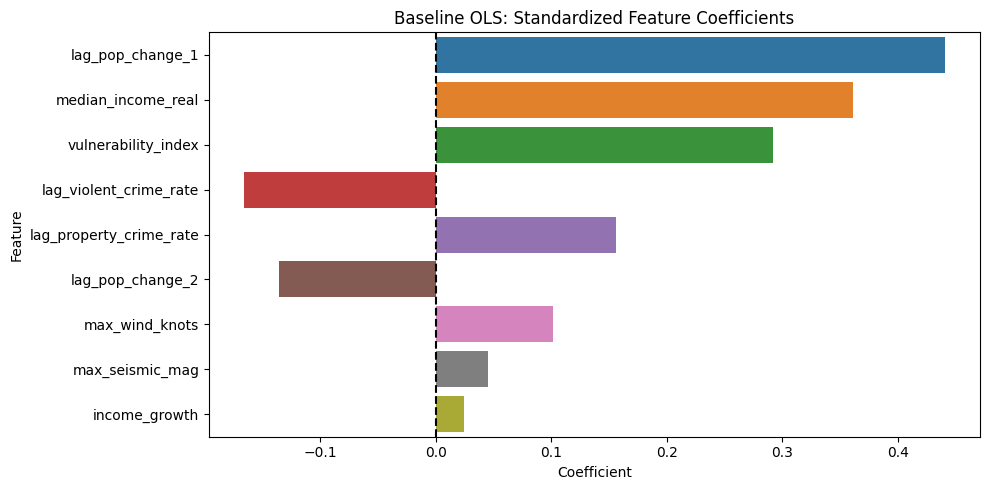

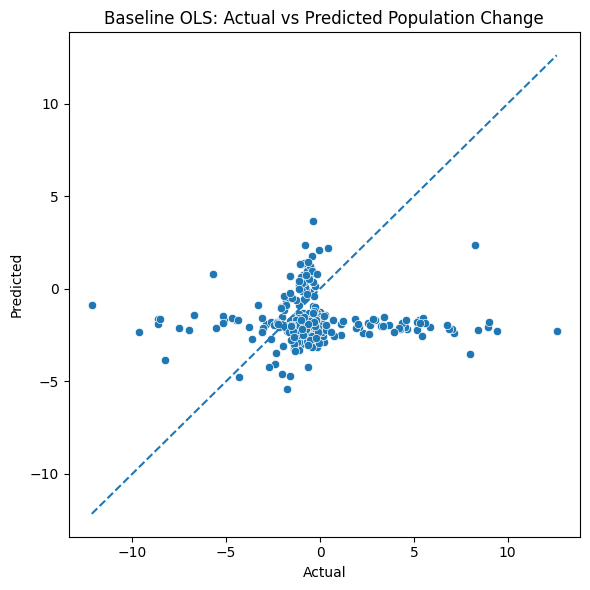

In [13]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -------------------------------
# 1. Metrics
# -------------------------------
r2_base = r2_score(y_test, y_pred_baseline)
mae_base = mean_absolute_error(y_test, y_pred_baseline)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

baseline_metrics_df = pd.DataFrame({
    'Metric': [
        'R-Squared (Explained Variance)',
        'Mean Absolute Error',
        'Root Mean Squared Error',
        'Train Rows',
        'Test Rows',
        'Train Years',
        'Test Years'
    ],
    'Value': [
        f"{r2_base:.4f}",
        f"{mae_base:.4f}",
        f"{rmse_base:.4f}",
        f"{len(X_train_raw)}",
        f"{len(X_test_raw)}",
        f"<= {train_end_year}",
        f">= {test_start_year}"
    ]
})

print("--- PHASE 1: Baseline OLS Model Performance ---")
display(baseline_metrics_df)

# -------------------------------
# 2. Coefficient table
# -------------------------------
coef_df = pd.DataFrame({
    'Feature': final_features,
    'Coefficient': baseline_model.coef_
}).sort_values(by='Coefficient', key=np.abs, ascending=False)

display(coef_df)

# -------------------------------
# 3. Coefficient plot
# -------------------------------
plt.figure(figsize=(10, 5))
sns.barplot(
    data=coef_df,
    x='Coefficient',
    y='Feature',
    hue='Feature',
    dodge=False,
    legend=False
)
plt.title('Baseline OLS: Standardized Feature Coefficients')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

# -------------------------------
# 4. Actual vs Predicted plot
# -------------------------------
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_baseline
})

plt.figure(figsize=(6, 6))
sns.scatterplot(data=results_df, x='Actual', y='Predicted')
plt.plot(
    [results_df['Actual'].min(), results_df['Actual'].max()],
    [results_df['Actual'].min(), results_df['Actual'].max()],
    linestyle='--'
)
plt.title('Baseline OLS: Actual vs Predicted Population Change')
plt.tight_layout()
plt.show()


## 4. Phase 1 Conclusion

Phase 1 establishes the project’s baseline modeling foundation.

### What was accomplished
1. A clean municipio-year modeling dataset was created.
2. The target variable was defined as annual population percent change.
3. Lagged crime variables were engineered to reflect delayed social-shock effects.
4. A vulnerability index was constructed from fifteen socioeconomic indicators using PCA.
5. New **autoregressive and economic-trend features** were added:
   - `lag_pop_change_1`
   - `lag_pop_change_2`
   - `income_growth`
6. A **time-aware, non-leaked OLS baseline** was trained and evaluated on a held-out future period.

### Why this phase matters
This notebook does not aim to maximize predictive accuracy. Its role is to:
- create a defensible feature pipeline,
- establish an interpretable benchmark,
- and provide a fair baseline for comparison with more flexible models in Phase 2.
